In [ ]:
!pip install numpy matplotlib opencv-python

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
image = cv2.imread("dog.jpg")

In [4]:
# cv2.imread carrega a imagem em BGR por padrão do OpenCV.
# Invertendo o eixo de canais com fatiamento NumPy obtemos a ordem RGB
# sem precisar de nenhuma função de conversão de biblioteca.
image = image[:, :, ::-1]

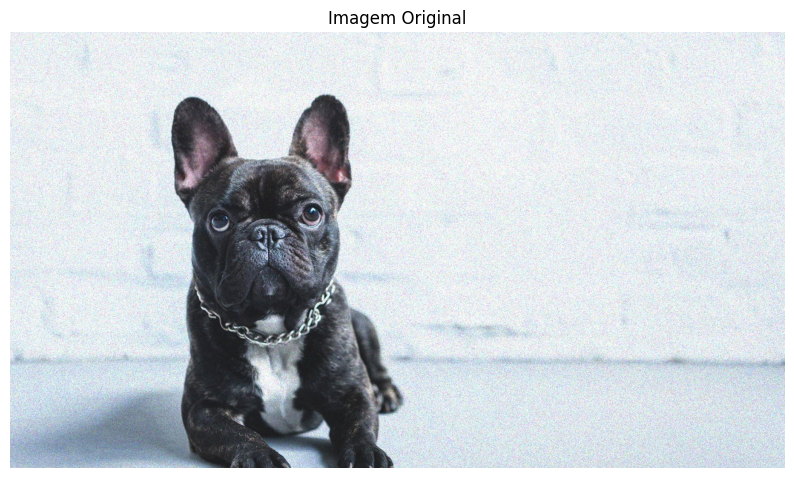

In [5]:
plt.figure(figsize=(10, 10))

plt.imshow(image)

plt.title("Imagem Original")

plt.axis("off")

plt.show()

In [6]:
# Converte para escala de cinza pela fórmula de luminância perceptiva.
# Os coeficientes ponderam R, G e B de acordo com a sensibilidade do olho
# humano: verde recebe o maior peso (0.587) por ser o canal mais visível.
def rgb_to_gray(image):

    height, width, _ = image.shape

    gray = np.zeros((height, width), dtype=np.uint8)

    for y in range(height):
        for x in range(width):

            r = image[y, x, 0]
            g = image[y, x, 1]
            b = image[y, x, 2]

            value = (
                0.299 * r +
                0.587 * g +
                0.114 * b
            )

            gray[y, x] = int(value)

    return gray

In [7]:
gray = rgb_to_gray(image)

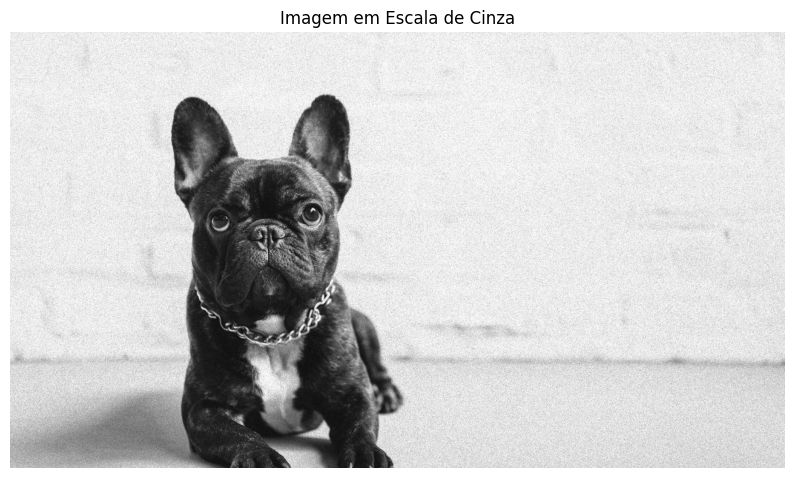

In [8]:
plt.figure(figsize=(10, 10))

plt.imshow(gray, cmap="gray")

plt.title("Imagem em Escala de Cinza")

plt.axis("off")

plt.show()

In [9]:
# Implementação de convolução 2D sem bibliotecas de visão computacional.
# O kernel desliza sobre cada pixel e calcula a soma ponderada da vizinhança,
# produzindo o valor filtrado naquele ponto.
# O padding 'edge' replica os valores das bordas da imagem para manter
# as dimensões originais e evitar artefatos escuros nas extremidades.
def convolve2d(image, kernel):

    image_height, image_width = image.shape

    kernel_height, kernel_width = kernel.shape

    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode='edge'
    )

    output = np.zeros_like(
        image,
        dtype=np.float32
    )

    for y in range(image_height):
        for x in range(image_width):

            region = padded[
                y:y+kernel_height,
                x:x+kernel_width
            ]

            value = np.sum(region * kernel)

            output[y, x] = value

    return output

In [10]:
# Kernel de média 3x3: borra levemente a imagem antes da detecção de bordas
# para suavizar ruído pontual que poderia gerar bordas falsas no gradiente.
mean_kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32) / 9

In [11]:
blurred = convolve2d(
    gray,
    mean_kernel
)

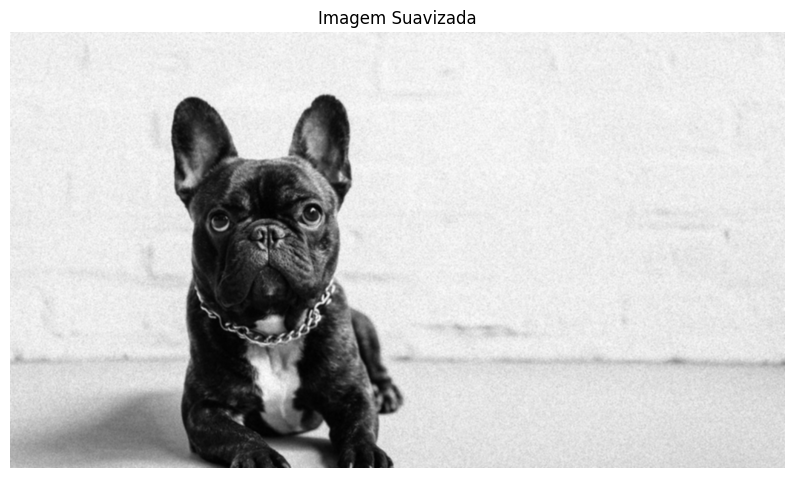

In [12]:
plt.figure(figsize=(10, 10))

plt.imshow(blurred, cmap="gray")

plt.title("Imagem Suavizada")

plt.axis("off")

plt.show()

In [13]:
# Kernels de Sobel para estimar o gradiente da intensidade em X e Y.
# sobel_x detecta variações horizontais de intensidade (bordas verticais) e
# sobel_y detecta variações verticais (bordas horizontais).
# Os pesos maiores na linha central (2) amplificam a direção principal.
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=np.float32)

In [14]:
grad_x = convolve2d(
    blurred,
    sobel_x
)

grad_y = convolve2d(
    blurred,
    sobel_y
)

In [15]:
# Combina os gradientes X e Y pela norma euclidiana.
# Valores altos indicam transições bruscas de intensidade, ou seja, bordas.
# Usar a raiz quadrada ao invés de apenas somar os quadrados preserva
# a unidade de magnitude e evita saturação prematura nos valores.
grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)

In [16]:
# Normaliza o gradiente para o intervalo [0, 255] antes de converter para uint8.
# Sem isso, valores float fora do intervalo seriam truncados na conversão
# e bordas mais fracas perderiam informação.
min_val = grad_magnitude.min()
max_val = grad_magnitude.max()

grad_magnitude = (
    (grad_magnitude - min_val) /
    (max_val - min_val)
) * 255

grad_magnitude = grad_magnitude.astype(np.uint8)

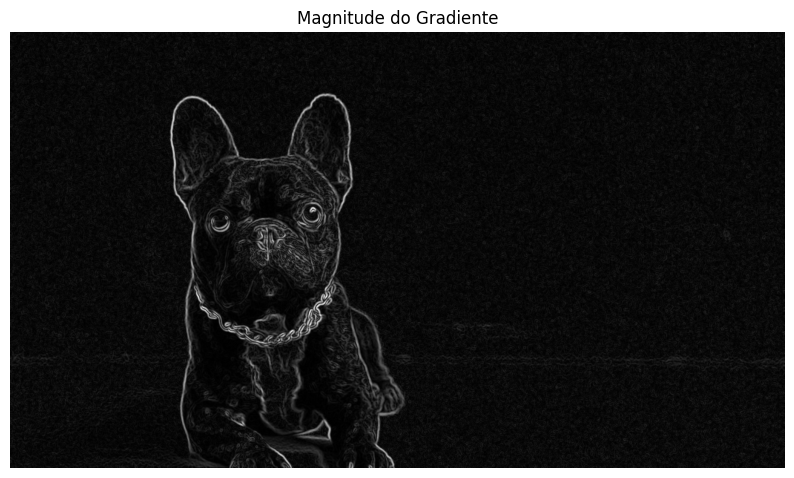

In [17]:
plt.figure(figsize=(10, 10))

plt.imshow(grad_magnitude, cmap="gray")

plt.title("Magnitude do Gradiente")

plt.axis("off")

plt.show()

In [ ]:
# Binariza a imagem do gradiente: pixels acima do limiar viram borda (255)
# e os demais viram fundo (0). O valor 30 foi ajustado para capturar o
# contorno do cachorro sem incluir ruído excessivo de fundo.
def threshold(image, thresh=30):

    output = np.zeros_like(image)

    height, width = image.shape

    for y in range(height):
        for x in range(width):

            if image[y, x] >= thresh:
                output[y, x] = 255
            else:
                output[y, x] = 0

    return output

In [19]:
# Dilatação morfológica com janela 3x3: se qualquer pixel da vizinhança
# for branco, o pixel central vira branco. Fecha lacunas pequenas entre
# segmentos de borda que deveriam ser contínuos mas ficaram separados.
def dilate(image):

    height, width = image.shape

    output = np.zeros_like(image)

    padded = np.pad(
        image,
        ((1, 1), (1, 1)),
        mode='constant'
    )

    for y in range(height):
        for x in range(width):

            region = padded[
                y:y+3,
                x:x+3
            ]

            if np.max(region) == 255:
                output[y, x] = 255

    return output

In [20]:
# Erosão morfológica com janela 3x3: o pixel só permanece branco se todos
# os vizinhos também forem brancos. Aplicada após a dilatação para restaurar
# a espessura original das bordas sem as lacunas que existiam antes.
def erode(image):

    height, width = image.shape

    output = np.zeros_like(image)

    padded = np.pad(
        image,
        ((1, 1), (1, 1)),
        mode='constant'
    )

    for y in range(height):
        for x in range(width):

            region = padded[
                y:y+3,
                x:x+3
            ]

            if np.min(region) == 255:
                output[y, x] = 255
            else:
                output[y, x] = 0

    return output

In [21]:
binary_edges = threshold(
    grad_magnitude,
    thresh=30
)

In [22]:
binary_edges = dilate(binary_edges)

binary_edges = erode(binary_edges)

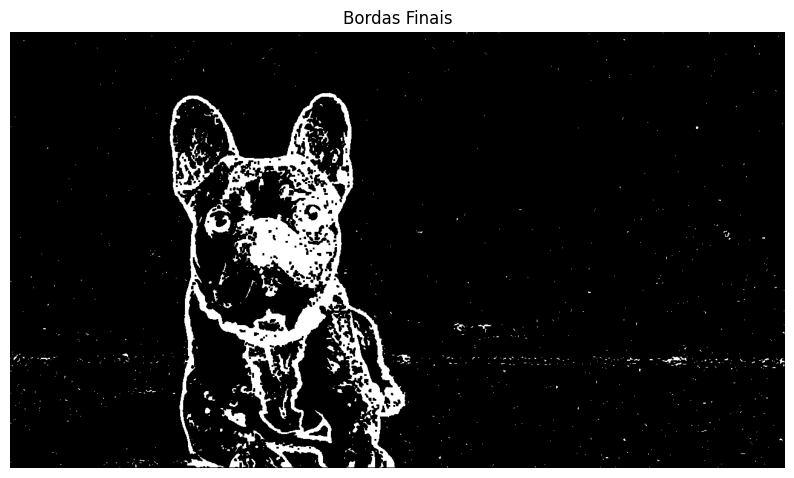

In [23]:
plt.figure(figsize=(10, 10))

plt.imshow(binary_edges, cmap="gray")

plt.title("Bordas Finais")

plt.axis("off")

plt.show()

In [24]:
# Rotulação de componentes conexos por busca em profundidade (DFS).
# np.argwhere pré-localiza todos os pixels brancos de uma vez, evitando
# varrer a imagem inteira linha a linha dentro do laço principal.
def _find_connected_components(binary_image):
    height, width = binary_image.shape
    visited = np.zeros((height, width), dtype=bool)
    components = []
    # 8-vizinhança: inclui diagonais para não fragmentar bordas inclinadas
    # que se tocam apenas em diagonal e pertencem ao mesmo contorno
    directions = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1)
    ]

    white_pixels = np.argwhere(binary_image == 255)

    for start_y, start_x in white_pixels:
        start_y, start_x = int(start_y), int(start_x)

        if visited[start_y, start_x]:
            continue

        component = []
        stack = [(start_y, start_x)]
        visited[start_y, start_x] = True

        while stack:
            y, x = stack.pop()
            component.append((x, y))  # formato (x, y)

            for dy, dx in directions:
                ny, nx = y + dy, x + dx
                if (
                    0 <= ny < height and
                    0 <= nx < width and
                    binary_image[ny, nx] == 255 and
                    not visited[ny, nx]
                ):
                    visited[ny, nx] = True
                    stack.append((ny, nx))

        components.append(component)

    return components


def extract_contour_points(binary_image):
    components = _find_connected_components(binary_image)

    filtered_points = []

    for component in components:
        # Componentes com menos de 50 pixels são descartados como ruído.
        # Contornos reais do objeto têm ordens de grandeza a mais do que
        # artefatos isolados gerados pelo gradiente em regiões de textura.
        if len(component) < 50:
            continue

        filtered_points.extend(component)

    return filtered_points

In [25]:
clean_edges = erode(binary_edges)

clean_edges = dilate(clean_edges)

contour_points = extract_contour_points(
    clean_edges
)

In [26]:
print(
    "Quantidade de pontos encontrados:",
    len(contour_points)
)

Quantidade de pontos encontrados: 10173


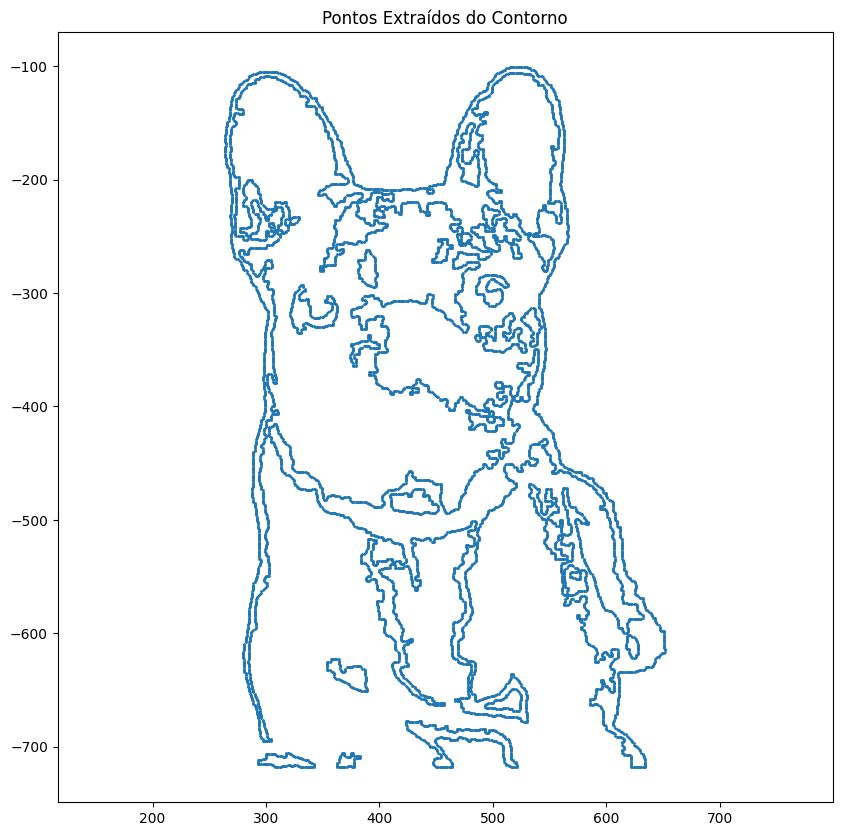

In [27]:
x_points = [p[0] for p in contour_points]

y_points = [p[1] for p in contour_points]

plt.figure(figsize=(10, 10))

# Invertendo eixo Y
# para coincidir visualmente com a imagem
plt.scatter(
    x_points,
    [-y for y in y_points],
    s=1
)

plt.title("Pontos Extraídos do Contorno")

plt.axis("equal")

plt.show()

In [ ]:
# Reduz a quantidade de pontos selecionando um a cada 'step' de elementos.
# Sai de ~10000 para ~2000 pontos, o suficiente para reproduzir o contorno
# no turtlesim com muito menos chamadas de serviço ROS 2.
def sample_points(points, step=5):

    return points[::step]

In [29]:
sampled_points = sample_points(
    contour_points,
    step=5
)

In [30]:
print(
    "Pontos originais:",
    len(contour_points)
)

print(
    "Pontos após amostragem:",
    len(sampled_points)
)

Pontos originais: 10173
Pontos após amostragem: 2035


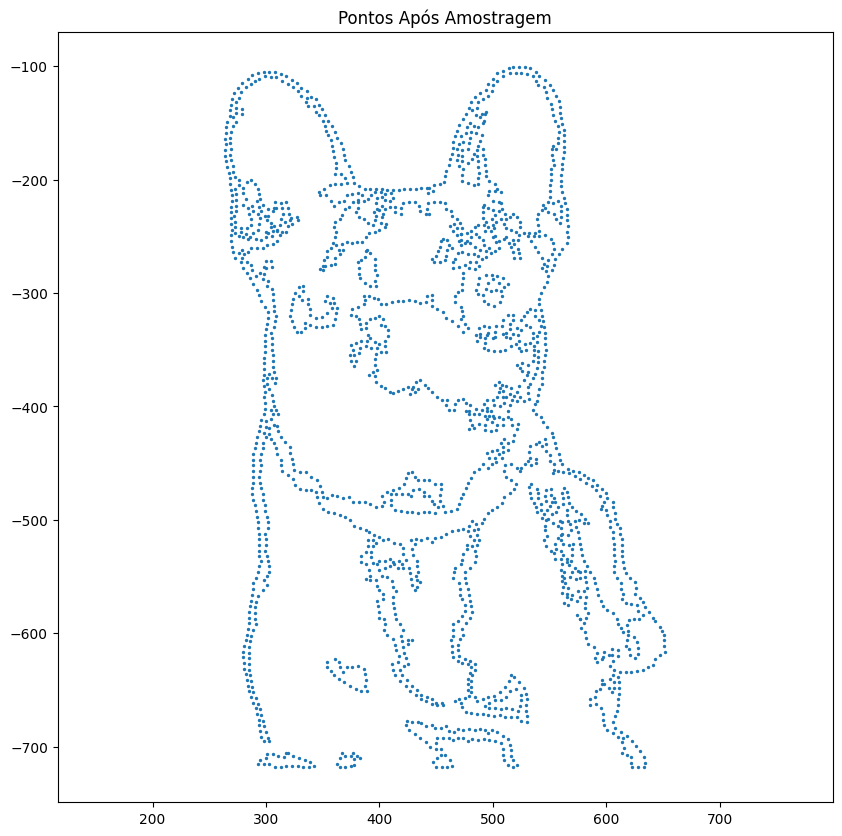

In [31]:
x_sampled = [p[0] for p in sampled_points]

y_sampled = [p[1] for p in sampled_points]

plt.figure(figsize=(10, 10))

plt.scatter(
    x_sampled,
    [-y for y in y_sampled],
    s=2
)

plt.title("Pontos Após Amostragem")

plt.axis("equal")

plt.show()

In [32]:
# Mapeia coordenadas de pixel para o espaço do turtlesim, que vai de 0 a 11
# em ambos os eixos. O eixo Y é invertido porque em imagens Y cresce de cima
# pra baixo, enquanto no turtlesim Y cresce de baixo pra cima como no plano
# cartesiano. Sem essa inversão o cachorro apareceria de cabeça pra baixo.
def map_to_turtlesim(
    points,
    image_width,
    image_height
):

    mapped_points = []

    for x, y in points:

        # Normaliza X proporcionalmente à largura da imagem
        turtle_x = (
            x / image_width
        ) * 11.0

        # Inverte e normaliza Y para corrigir a orientação vertical
        turtle_y = 11.0 - (
            (y / image_height) * 11.0
        )

        mapped_points.append(
            (turtle_x, turtle_y)
        )

    return mapped_points

In [33]:
image_height, image_width = binary_edges.shape

In [34]:
turtle_points = map_to_turtlesim(
    sampled_points,
    image_width,
    image_height
)

In [35]:
print(
    "Quantidade de pontos mapeados:",
    len(turtle_points)
)

Quantidade de pontos mapeados: 2035


Text(0.5, 1.0, 'Pontos Mapeados para o Turtlesim')

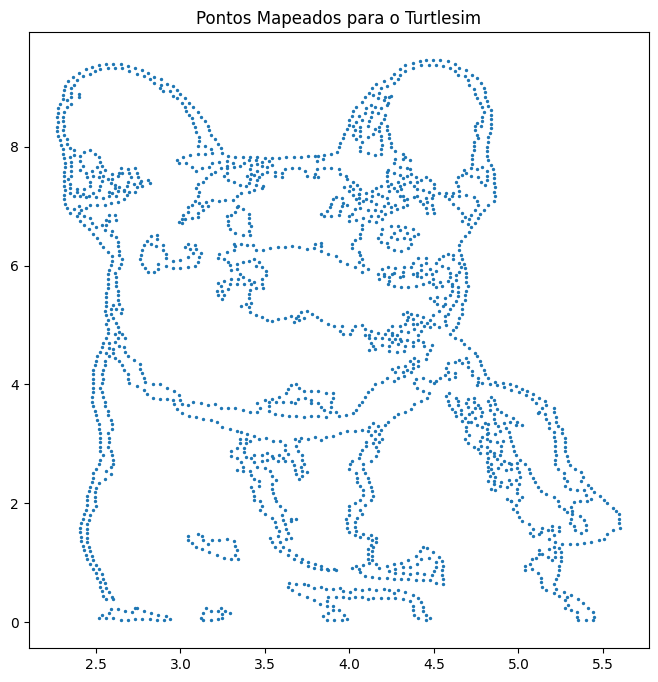

In [36]:
turtle_x = [p[0] for p in turtle_points]

turtle_y = [p[1] for p in turtle_points]

plt.figure(figsize=(8, 8))

plt.scatter(
    turtle_x,
    turtle_y,
    s=2
)

plt.title("Pontos Mapeados para o Turtlesim")

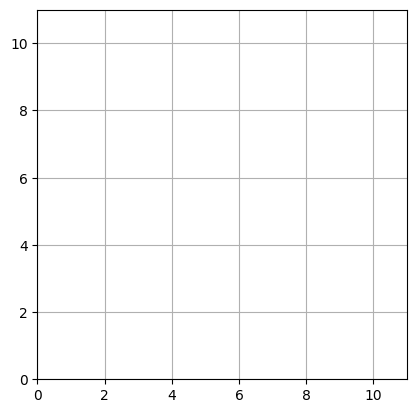

In [37]:
plt.xlim(0, 11)
plt.ylim(0, 11)

plt.gca().set_aspect('equal')

plt.grid()

plt.show()

In [38]:
np.save(
    "turtle_points.npy",
    turtle_points
)

print(
    "Pontos do turtlesim salvos com sucesso."
)

Pontos do turtlesim salvos com sucesso.
